In [1]:
!pip install numpy pandas torch scikit-learn tensorflow deepctr-torch

In [2]:
#################################
# Import Libraries
#################################
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from deepctr_torch.inputs import SparseFeat, get_feature_names
from deepctr_torch.models import DeepFM
import matplotlib.pyplot as plt
import os

#################################
# Utility Functions
#################################
def compute_mahalanobis_distance(mean, cov_inv, embedding):
    diff = embedding - mean
    return np.sqrt(diff.T @ cov_inv @ diff)

class DriftDetector:
    def __init__(self, embedding_dim, alpha=0.01):
        self.alpha = alpha
        self.mean = np.zeros(embedding_dim)
        self.cov = np.eye(embedding_dim)
        self.count = 0

    def update(self, embedding):
        if self.count == 0:
            self.mean = embedding
            self.cov = np.eye(len(embedding))
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding
            diff = embedding - self.mean
            self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(diff, diff)
        self.count += 1

    def detect_drift(self, embedding):
        return compute_mahalanobis_distance(self.mean, np.linalg.pinv(self.cov), embedding)

#################################
# Load and Preprocess Data
#################################
data = pd.read_json("experiment_1/Amazon_Fashion.jsonl", lines=True)
data = data[data["rating"] != 3]
data = data[data["timestamp"] > '2015-01-01']
data["year"] = data["timestamp"].apply(lambda x: x.year)
data["month"] = data["timestamp"].apply(lambda x: x.month)
data["day"] = data["timestamp"].apply(lambda x: x.day)
data["rating"] = data["rating"].transform(lambda x: 1 if x > 3 else 0)

data.set_index(data["timestamp"], inplace=True)
data.sort_index(inplace=True)
data_sample = data

#################################
# Define Features and Model
#################################
sparse_features = ["parent_asin", "user_id", "year", "month", "day"]
target = ['rating']

# Label Encoding for sparse features
for feat in sparse_features:
    lbe = LabelEncoder()
    data[feat] = lbe.fit_transform(data[feat])

# Define feature columns
embedding_dim = 8
fixlen_feature_columns = [
    SparseFeat(feat, data[feat].nunique(), embedding_dim=embedding_dim)
    for feat in sparse_features
]
linear_feature_columns = fixlen_feature_columns
dnn_feature_columns = fixlen_feature_columns
feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

# Prepare model input
model_input = {name: data[name] for name in sparse_features}

# Define and compile the model
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
model = DeepFM(linear_feature_columns, dnn_feature_columns, task='binary', device=device)
model.compile("adam", metrics=["AUC"], loss='binary_crossentropy')

# Train the model
history = model.fit(
    model_input,
    data_sample[target].values,
    batch_size=1024,
    epochs=6,
    verbose=2,
    validation_split=0.1
)


mps
Train on 1950237 samples, validate on 216694 samples, 1905 steps per epoch
Epoch 1/6
68s - loss:  0.4853
Epoch 2/6
60s - loss:  0.1324
Epoch 3/6
65s - loss:  0.0718
Epoch 4/6
61s - loss:  0.0395
Epoch 5/6
62s - loss:  0.0222
Epoch 6/6
65s - loss:  0.0167


In [21]:
#################################
# Mahalanobis Drift Detection Setup
#################################
# Drift detection parameters
window_size = 10
threshold_multiplier = 2
alpha = 0.01  # Faster adaptation to changes

tracker = DriftDetector(embedding_dim, alpha=alpha)
drift_distances = []
thresholds = []

# Generate embeddings for drift detection
with torch.no_grad():
    for batch_index, batch in enumerate(np.array_split(data_sample[sparse_features], 300)):
        batch_input = {key: batch[key].values for key in sparse_features}
        embeddings = model.predict(batch_input)
        mean_embedding = np.mean(embeddings, axis=0)

        tracker.update(mean_embedding)
        drift_distance = tracker.detect_drift(mean_embedding)
        drift_distances.append(drift_distance)

        # Dynamic threshold calculation
        if len(drift_distances) > window_size:
            recent_dists = drift_distances[-window_size:]
            mean_dist = np.mean(recent_dists)
            std_dist = np.std(recent_dists)
            threshold = mean_dist + threshold_multiplier * std_dist
        else:
            threshold = np.mean(drift_distances) + threshold_multiplier * np.std(drift_distances)

        thresholds.append(threshold)

        # Drift detection
        if drift_distance > threshold:
            print(f"Batch {batch_index}: Drift detected! Distance = {drift_distance:.4f}, Threshold = {threshold:.4f}")
#################################
# Save Results
#################################
distances_path = "drift_distances_dl.npy"
thresholds_path = "drift_thresholds_dl.npy"
np.save(distances_path, drift_distances)
np.save(thresholds_path, thresholds)
print("Drift detection results saved.")

/opt/anaconda3/envs/cad_pointcloud/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Batch 15: Drift detected! Distance = 0.0370, Threshold = 0.0362
Batch 42: Drift detected! Distance = 0.0530, Threshold = 0.0506
Batch 72: Drift detected! Distance = 0.0689, Threshold = 0.0686
Batch 73: Drift detected! Distance = 0.0742, Threshold = 0.0739
Batch 76: Drift detected! Distance = 0.1059, Threshold = 0.0980
Batch 93: Drift detected! Distance = 0.0997, Threshold = 0.0967
Batch 113: Drift detected! Distance = 0.0822, Threshold = 0.0778
Batch 208: Drift detected! Distance = 0.1238, Threshold = 0.0981
Batch 209: Drift detected! Distance = 0.1374, Threshold = 0.1341
Batch 250: Drift detected! Distance = 0.2221, Threshold = 0.2218
Batch 260: Drift detected! Distance = 0.2639, Threshold = 0.2562
Batch 262: Drift detected! Distance = 0.2877, Threshold = 0.2834
Batch 265: Drift detected! Distance = 0.3309, Threshold = 0.3255
Batch 270: Drift detected! Distance = 1.3223, Threshold = 1.0146
Batch 271: Drift detected! Distance = 1.3607, Threshold = 1.3433
Drift detection results saved.


Mean Distance: 0.1608
Std Distance: 0.2945
Number of Drifts: 15/300


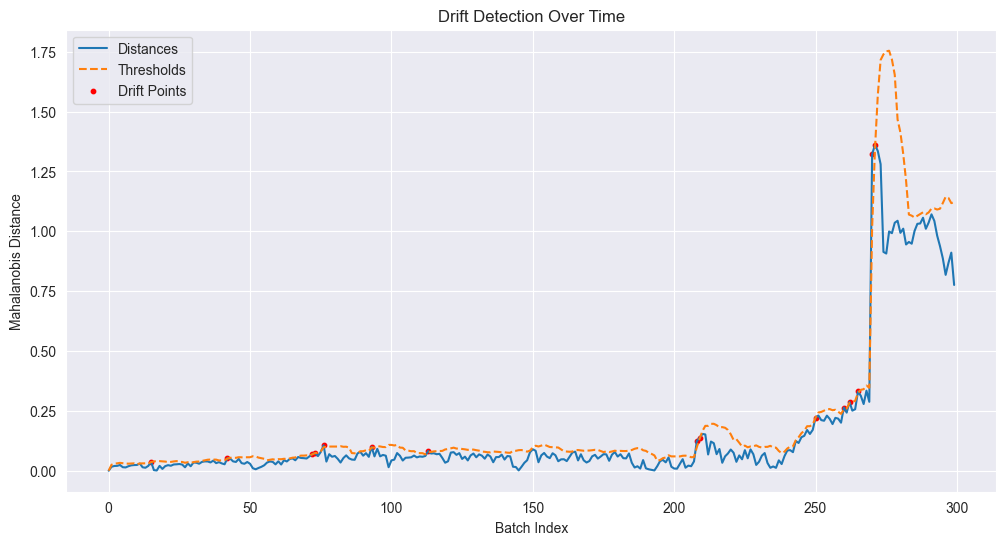

In [22]:
#################################
# Visualization
#################################
import numpy as np
import matplotlib.pyplot as plt

# Load distances and thresholds
distances = np.load('drift_distances_dl.npy')
thresholds = np.load('drift_thresholds_dl.npy')

# Mask to identify drift points
drift_mask = distances > thresholds

# Summary statistics
mean_distance = np.mean(distances)
std_distance = np.std(distances)
num_drifts = np.sum(drift_mask)

print(f"Mean Distance: {mean_distance:.4f}")
print(f"Std Distance: {std_distance:.4f}")
print(f"Number of Drifts: {num_drifts}/{len(distances)}")


plt.figure(figsize=(12, 6))
plt.plot(distances, label="Distances")
plt.plot(thresholds, label="Thresholds", linestyle="--")
plt.scatter(np.arange(len(distances))[drift_mask], distances[drift_mask], color='red', s=10, label="Drift Points")
plt.xlabel('Batch Index')
plt.ylabel('Mahalanobis Distance')
plt.title('Drift Detection Over Time')
plt.legend()
plt.savefig('drift_over_time_dl.png')
plt.show()

pre_drift_distances = distances[~drift_mask]
post_drift_distances = distances[drift_mask]

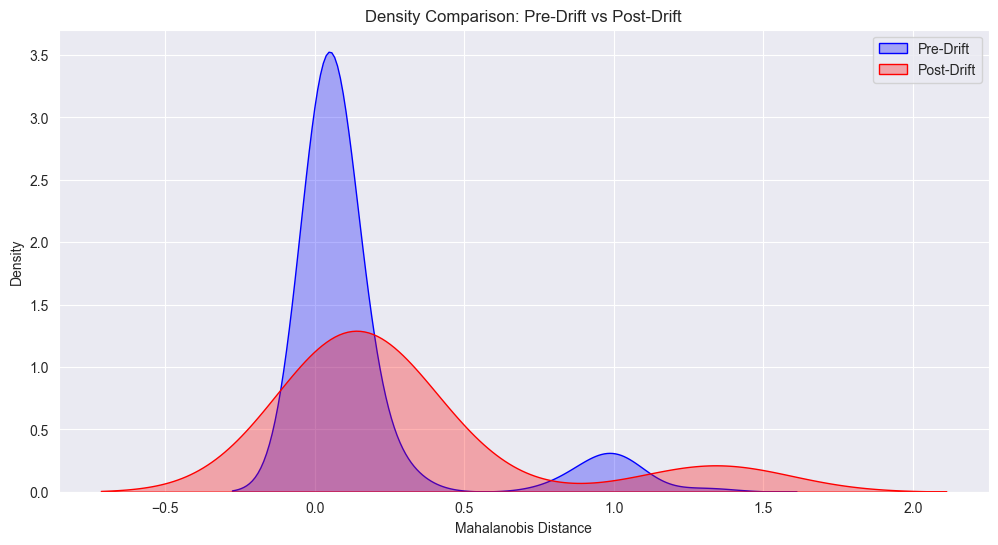

In [24]:
import seaborn as sns

# Plot density comparison
plt.figure(figsize=(12, 6))
sns.kdeplot(pre_drift_distances, label="Pre-Drift", color="blue", fill=True, alpha=0.6)
sns.kdeplot(post_drift_distances, label="Post-Drift", color="red", fill=True, alpha=0.6)
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Density")
plt.title("Density Comparison: Pre-Drift vs Post-Drift")
plt.legend()
plt.savefig("density_comparison_dl.png")
plt.show()
